In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display all columns
pd.set_option("display.max_columns", None)

In [57]:
# Load restaurant dataset
import pandas as pd

restaurants = pd.read_csv(r"C:\Users\ADMIN\OneDrive\Desktop\fast_food_restaurant_analysis\fast-food-restaurant-analysis\data\raw\fast_food_restaurants.csv")

In [58]:
restaurants.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   address     10000 non-null  str    
 1   city        10000 non-null  str    
 2   country     10000 non-null  str    
 3   keys        10000 non-null  str    
 4   latitude    10000 non-null  float64
 5   longitude   10000 non-null  float64
 6   name        10000 non-null  str    
 7   postalCode  10000 non-null  str    
 8   province    10000 non-null  str    
 9   websites    9535 non-null   str    
dtypes: float64(2), str(8)
memory usage: 781.4 KB


In [59]:
restaurants.columns

Index(['address', 'city', 'country', 'keys', 'latitude', 'longitude', 'name',
       'postalCode', 'province', 'websites'],
      dtype='str')

In [60]:
restaurants.isnull().sum()

address         0
city            0
country         0
keys            0
latitude        0
longitude       0
name            0
postalCode      0
province        0
websites      465
dtype: int64

In [61]:
city_counts = (
    restaurants.groupby(["city", "province"])
    .size()
    .reset_index(name="restaurant_count")
)

city_counts.head()

,city,province,restaurant_count
0,Abbeville,LA,2
1,Aberdeen,MD,1
2,Aberdeen,NC,1
3,Aberdeen,SD,10
4,Aberdeen,WA,6


In [62]:
print(restaurants.columns.tolist())

['address', 'city', 'country', 'keys', 'latitude', 'longitude', 'name', 'postalCode', 'province', 'websites']


In [63]:
population = pd.read_csv("city_population.csv")

population.head()

FileNotFoundError: [Errno 2] No such file or directory: 'city_population.csv'

In [ ]:
import os

for root, dirs, files in os.walk("."):
    for file in files:
        print(os.path.join(root, file))

.\.gitkeep
.\question6.ipynb
.\report_tarun.md


In [ ]:
import os

for root, dirs, files in os.walk("../"):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

../charts\question3_results.csv
../data\processed\merged_restaurant_data.csv
../data\raw\city_population.csv
../data\raw\fast_food_restaurants.csv
../data\raw\state_population.csv


In [ ]:
population = pd.read_csv("../data/raw/city_population.csv")

population.head()

,city,city_ascii,state_id,state_name,county_fips,county_name,lat,lng,population,density,source,military,incorporated,timezone,ranking,zips,id
0,New York,New York,NY,New York,36081,Queens,40.6943,-73.9249,19268388,10943.7,shape,False,True,America/New_York,1,11229 11228 11226 11225 11224 11222 11221 1122...,1840034016
1,Los Angeles,Los Angeles,CA,California,6037,Los Angeles,34.1141,-118.4068,11984083,3165.7,shape,False,True,America/Los_Angeles,1,91367 90291 90293 90292 91316 91311 90035 9003...,1840020491
2,Chicago,Chicago,IL,Illinois,17031,Cook,41.8375,-87.6866,8609571,4590.3,shape,False,True,America/Chicago,1,60018 60649 60641 60640 60643 60642 60645 6064...,1840000494
3,Miami,Miami,FL,Florida,12086,Miami-Dade,25.7840,-80.2101,6391670,4791.1,shape,False,True,America/New_York,1,33128 33129 33125 33126 33127 33149 33144 3314...,1840015149
4,Houston,Houston,TX,Texas,48201,Harris,29.7860,-95.3885,6227666,1386.2,shape,False,True,America/Chicago,1,77069 77068 77061 77060 77063 77062 77065 7706...,1840020925


In [ ]:
print(population.columns.tolist())

['city', 'city_ascii', 'state_id', 'state_name', 'county_fips', 'county_name', 'lat', 'lng', 'population', 'density', 'source', 'military', 'incorporated', 'timezone', 'ranking', 'zips', 'id']


In [ ]:
city_counts = (
    restaurants.groupby(["city", "province"])
    .size()
    .reset_index(name="restaurant_count")
)

city_counts.head()

,city,province,restaurant_count
0,Abbeville,LA,2
1,Aberdeen,MD,1
2,Aberdeen,NC,1
3,Aberdeen,SD,10
4,Aberdeen,WA,6


In [ ]:
merged = pd.merge(
    city_counts,
    population,
    left_on=["city", "province"],
    right_on=["city", "state_name"],
    how="inner"
)

merged.head()

,city,province,restaurant_count,city_ascii,state_id,state_name,county_fips,county_name,lat,lng,population,density,source,military,incorporated,timezone,ranking,zips,id


In [ ]:
print("Restaurant cities:", len(city_counts))
print("Matched cities:", len(merged))

Restaurant cities: 3439
Matched cities: 0


In [ ]:
print(restaurants["province"].unique()[:20])

<StringArray>
['NY', 'OH', 'KY', 'SC', 'AR', 'OK', 'IN', 'NC', 'TN', 'TX', 'LA', 'KS', 'ND',
 'UT', 'GA', 'NM', 'OR', 'HI', 'VT', 'MI']
Length: 20, dtype: str


In [ ]:
print(population["state_name"].unique()[:20])

<StringArray>
[            'New York',           'California',             'Illinois',
              'Florida',                'Texas',         'Pennsylvania',
              'Georgia', 'District of Columbia',        'Massachusetts',
              'Arizona',             'Michigan',           'Washington',
            'Minnesota',             'Colorado',               'Nevada',
             'Maryland',             'Missouri',               'Oregon',
          'Puerto Rico',              'Indiana']
Length: 20, dtype: str


In [ ]:
state_map = {
    "AL":"Alabama",
    "AK":"Alaska",
    "AZ":"Arizona",
    "AR":"Arkansas",
    "CA":"California",
    "CO":"Colorado",
    "CT":"Connecticut",
    "DE":"Delaware",
    "FL":"Florida",
    "GA":"Georgia",
    "HI":"Hawaii",
    "ID":"Idaho",
    "IL":"Illinois",
    "IN":"Indiana",
    "IA":"Iowa",
    "KS":"Kansas",
    "KY":"Kentucky",
    "LA":"Louisiana",
    "ME":"Maine",
    "MD":"Maryland",
    "MA":"Massachusetts",
    "MI":"Michigan",
    "MN":"Minnesota",
    "MS":"Mississippi",
    "MO":"Missouri",
    "MT":"Montana",
    "NE":"Nebraska",
    "NV":"Nevada",
    "NH":"New Hampshire",
    "NJ":"New Jersey",
    "NM":"New Mexico",
    "NY":"New York",
    "NC":"North Carolina",
    "ND":"North Dakota",
    "OH":"Ohio",
    "OK":"Oklahoma",
    "OR":"Oregon",
    "PA":"Pennsylvania",
    "RI":"Rhode Island",
    "SC":"South Carolina",
    "SD":"South Dakota",
    "TN":"Tennessee",
    "TX":"Texas",
    "UT":"Utah",
    "VT":"Vermont",
    "VA":"Virginia",
    "WA":"Washington",
    "WV":"West Virginia",
    "WI":"Wisconsin",
    "WY":"Wyoming",
    "DC":"District of Columbia"
}

In [ ]:
city_counts["state_name"] = city_counts["province"].map(state_map)

city_counts.head()

,city,province,restaurant_count,state_name
0,Abbeville,LA,2,Louisiana
1,Aberdeen,MD,1,Maryland
2,Aberdeen,NC,1,North Carolina
3,Aberdeen,SD,10,South Dakota
4,Aberdeen,WA,6,Washington


In [ ]:
merged = pd.merge(
    city_counts,
    population,
    on=["city", "state_name"],
    how="inner"
)

print("Matched cities:", len(merged))

merged.head()

Matched cities: 3051


,city,province,restaurant_count,state_name,city_ascii,state_id,county_fips,county_name,lat,lng,population,density,source,military,incorporated,timezone,ranking,zips,id
0,Abbeville,LA,2,Louisiana,Abbeville,LA,22113,Vermilion,29.9751,-92.1265,11003,707.9,shape,False,True,America/Chicago,3,70510 70511,1840014005
1,Aberdeen,MD,1,Maryland,Aberdeen,MD,24025,Harford,39.5151,-76.1733,17298,933.5,shape,False,True,America/New_York,3,21001,1840005666
2,Aberdeen,NC,1,North Carolina,Aberdeen,NC,37125,Moore,35.1350,-79.4326,9228,319.6,shape,False,True,America/New_York,3,28315,1840015433
3,Aberdeen,SD,10,South Dakota,Aberdeen,SD,46013,Brown,45.4649,-98.4686,28189,659.2,shape,False,True,America/Chicago,3,57401,1840002032
4,Aberdeen,WA,6,Washington,Aberdeen,WA,53027,Grays Harbor,46.9757,-123.8094,17088,605.1,shape,False,True,America/Los_Angeles,3,98520,1840018446


In [ ]:
small_cities = merged[
    (merged["population"] >= 10000) &
    (merged["population"] < 100000)
].copy()

print("Number of small cities:", len(small_cities))

Number of small cities: 1501


In [ ]:
small_cities["restaurants_per_10000"] = (
    small_cities["restaurant_count"] /
    small_cities["population"]
) * 10000

In [ ]:
top_small = small_cities.sort_values(
    by="restaurants_per_10000",
    ascending=False
)

top_small.head(20)

,city,province,restaurant_count,state_name,city_ascii,state_id,county_fips,county_name,lat,lng,population,density,source,military,incorporated,timezone,ranking,zips,id,restaurants_per_10000
1844,Mount Airy,NC,12,North Carolina,Mount Airy,NC,37171,Surry,36.5083,-80.6155,10633,350.4,shape,False,True,America/New_York,3,27030,1840014430,11.285620
1940,Newport,KY,15,Kentucky,Newport,KY,21037,Campbell,39.0856,-84.4868,13967,1965.3,shape,False,True,America/New_York,3,41071 41072,1840014261,10.739600
635,Covington,LA,9,Louisiana,Covington,LA,22103,St. Tammany,30.4810,-90.1122,11658,555.3,shape,False,True,America/Chicago,3,70433,1840015019,7.720021
546,Cleveland,MS,8,Mississippi,Cleveland,MS,28011,Bolivar,33.7440,-90.7285,10623,553.1,shape,False,True,America/Chicago,3,38732 38733,1840014748,7.530829
1009,Glasgow,KY,11,Kentucky,Glasgow,KY,21009,Barren,37.0048,-85.9263,15197,362.8,shape,False,True,America/Chicago,3,42141 42142,1840013268,7.238271
425,Carroll,IA,7,Iowa,Carroll,IA,19027,Carroll,42.0699,-94.8646,10208,659.0,shape,False,True,America/Chicago,3,51401,1840000490,6.857367
2192,Placerville,CA,7,California,Placerville,CA,6017,El Dorado,38.7308,-120.7979,10762,709.4,shape,False,True,America/Los_Angeles,3,95667,1840020238,6.504367
2762,Traverse City,MI,10,Michigan,Traverse City,MI,26055,Grand Traverse,44.7546,-85.6038,15593,722.7,shape,False,True,America/Detroit,3,49686 49684,1840003946,6.413134
1707,Meadville,PA,8,Pennsylvania,Meadville,PA,42039,Crawford,41.6476,-80.1468,12577,1126.2,shape,False,True,America/New_York,3,16335 16388,1840000558,6.360817
271,Bloomsburg,PA,8,Pennsylvania,Bloomsburg,PA,42037,Columbia,41.0027,-76.4561,13024,1146.1,shape,False,True,America/New_York,3,17815,1840000811,6.142506


In [ ]:
top10 = top_small[
    [
        "city",
        "state_name",
        "restaurant_count",
        "population",
        "restaurants_per_10000"
    ]
].head(10)

top10

,city,state_name,restaurant_count,population,restaurants_per_10000
1844,Mount Airy,North Carolina,12,10633,11.285620
1940,Newport,Kentucky,15,13967,10.739600
635,Covington,Louisiana,9,11658,7.720021
546,Cleveland,Mississippi,8,10623,7.530829
1009,Glasgow,Kentucky,11,15197,7.238271
425,Carroll,Iowa,7,10208,6.857367
2192,Placerville,California,7,10762,6.504367
2762,Traverse City,Michigan,10,15593,6.413134
1707,Meadville,Pennsylvania,8,12577,6.360817
271,Bloomsburg,Pennsylvania,8,13024,6.142506


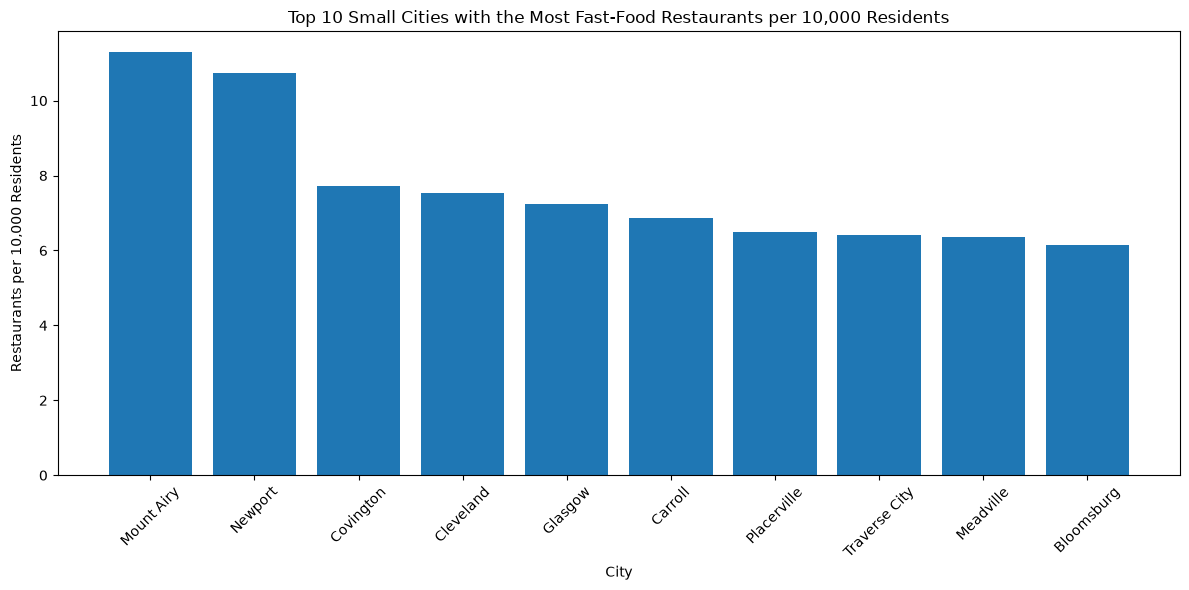

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(
    top10["city"],
    top10["restaurants_per_10000"]
)

plt.title("Top 10 Small Cities with the Most Fast-Food Restaurants per 10,000 Residents")

plt.xlabel("City")
plt.ylabel("Restaurants per 10,000 Residents")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [ ]:
top10.to_csv("question6_top10.csv", index=False)

In [ ]:
print(top10)

               city      state_name  restaurant_count  population  \
1844     Mount Airy  North Carolina                12       10633   
1940        Newport        Kentucky                15       13967   
635       Covington       Louisiana                 9       11658   
546       Cleveland     Mississippi                 8       10623   
1009        Glasgow        Kentucky                11       15197   
425         Carroll            Iowa                 7       10208   
2192    Placerville      California                 7       10762   
2762  Traverse City        Michigan                10       15593   
1707      Meadville    Pennsylvania                 8       12577   
271      Bloomsburg    Pennsylvania                 8       13024   

      restaurants_per_10000  
1844              11.285620  
1940              10.739600  
635                7.720021  
546                7.530829  
1009               7.238271  
425                6.857367  
2192               6.504367  


In [ ]:
import os

os.listdir()

['.gitkeep', 'question6.ipynb', 'question6_top10.csv', 'report_tarun.md']

In [ ]:
top10

,city,state_name,restaurant_count,population,restaurants_per_10000
1844,Mount Airy,North Carolina,12,10633,11.285620
1940,Newport,Kentucky,15,13967,10.739600
635,Covington,Louisiana,9,11658,7.720021
546,Cleveland,Mississippi,8,10623,7.530829
1009,Glasgow,Kentucky,11,15197,7.238271
425,Carroll,Iowa,7,10208,6.857367
2192,Placerville,California,7,10762,6.504367
2762,Traverse City,Michigan,10,15593,6.413134
1707,Meadville,Pennsylvania,8,12577,6.360817
271,Bloomsburg,Pennsylvania,8,13024,6.142506


In [ ]:
top10.to_csv("question6_top10.csv", index=False)

In [ ]:
import os

print(os.listdir())

['.gitkeep', 'question6.ipynb', 'question6_top10.csv', 'report_tarun.md']


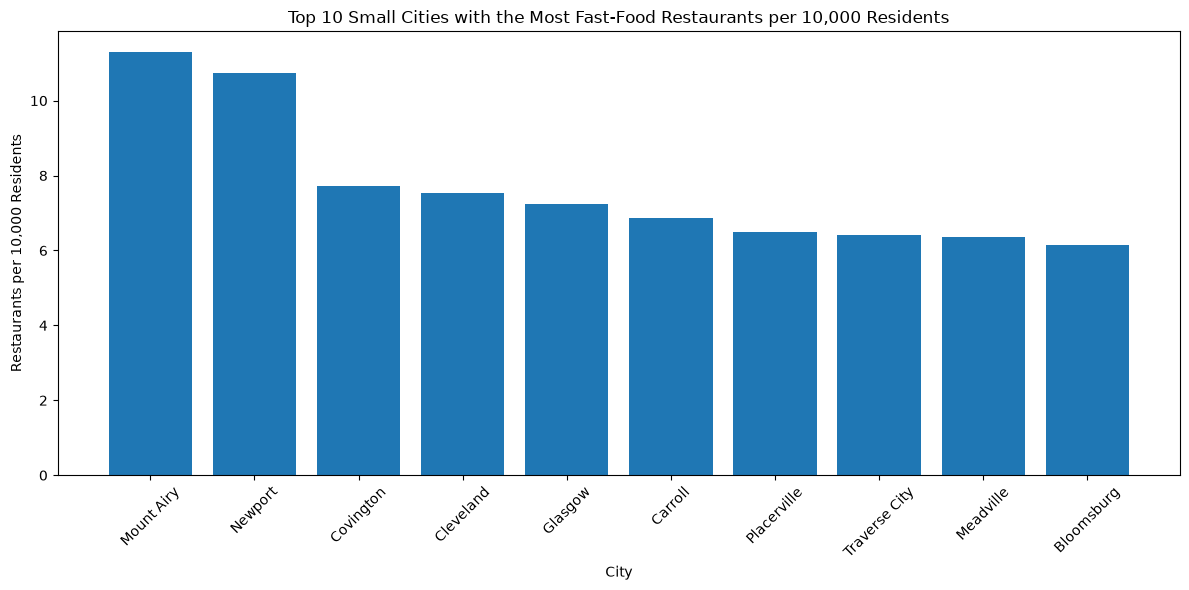

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(
    top10["city"],
    top10["restaurants_per_10000"]
)

plt.title("Top 10 Small Cities with the Most Fast-Food Restaurants per 10,000 Residents")
plt.xlabel("City")
plt.ylabel("Restaurants per 10,000 Residents")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("question6_chart.png", dpi=300)

plt.show()

In [ ]:
import os

print(os.listdir())

['.gitkeep', 'question6.ipynb', 'question6_chart.png', 'question6_top10.csv', 'report_tarun.md']


# Conclusion

This analysis identified small cities with the highest number of fast-food restaurants per capita.

The restaurant data was grouped by city and merged with city population data. Cities with populations between 10,000 and 100,000 were classified as small cities. The number of restaurants per 10,000 residents was then calculated to compare restaurant density across cities.

The results show that Mount Airy (North Carolina) has the highest concentration of fast-food restaurants per 10,000 residents, followed by Newport (Kentucky). These findings suggest that some small cities have a relatively high density of fast-food restaurants compared to their population.